 Bagging Visualization Examples

1. Bootstrap Sampling Process...


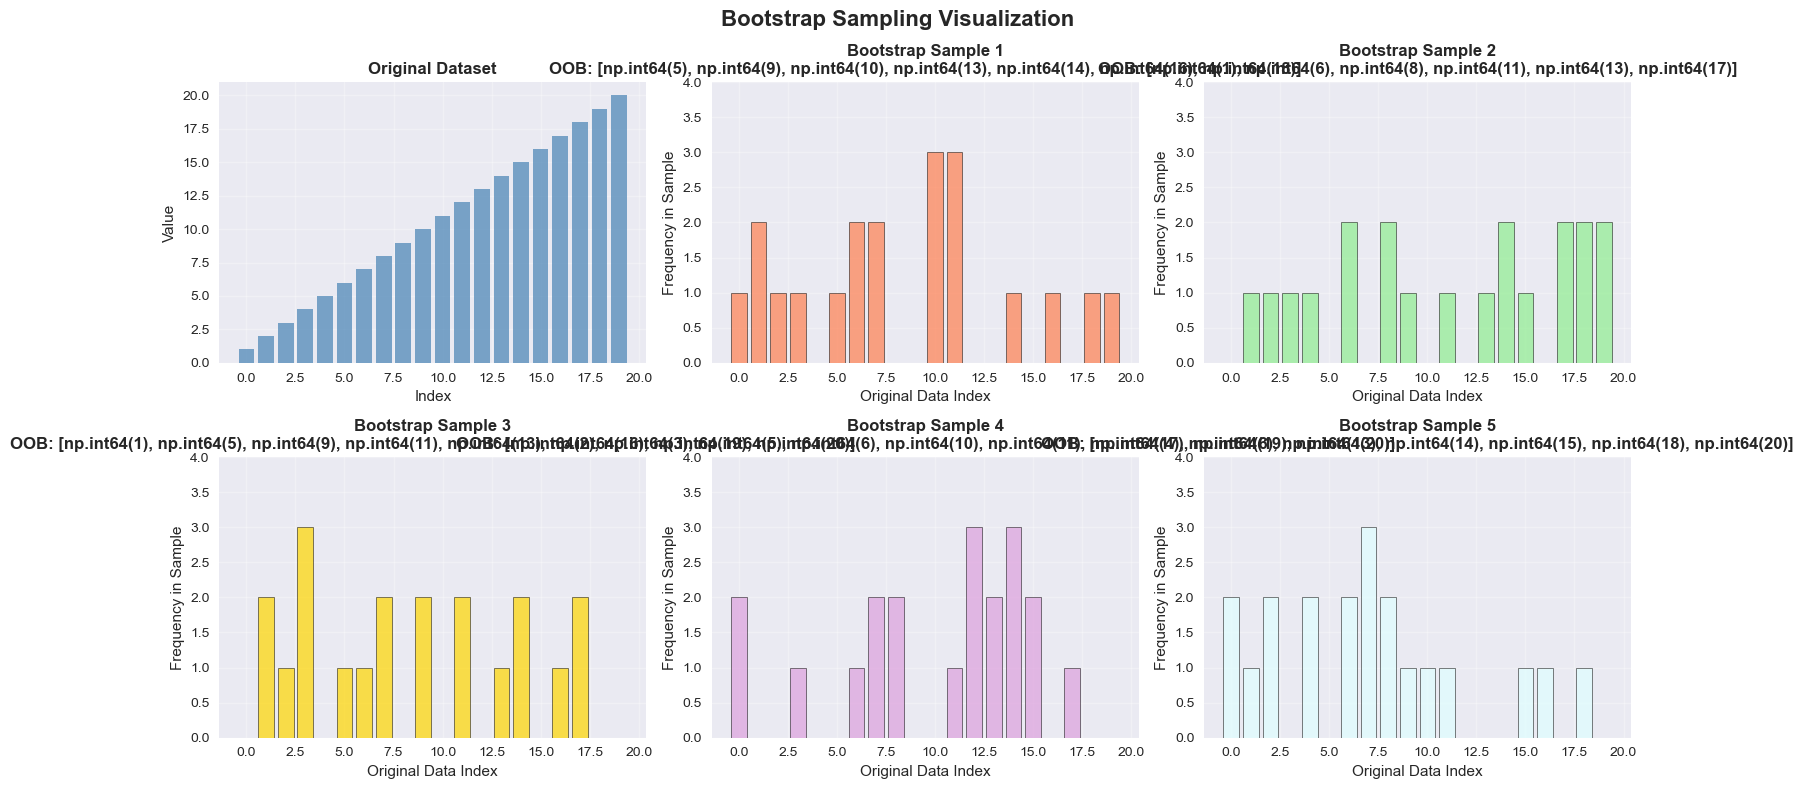


2. Decision Boundary Comparison...


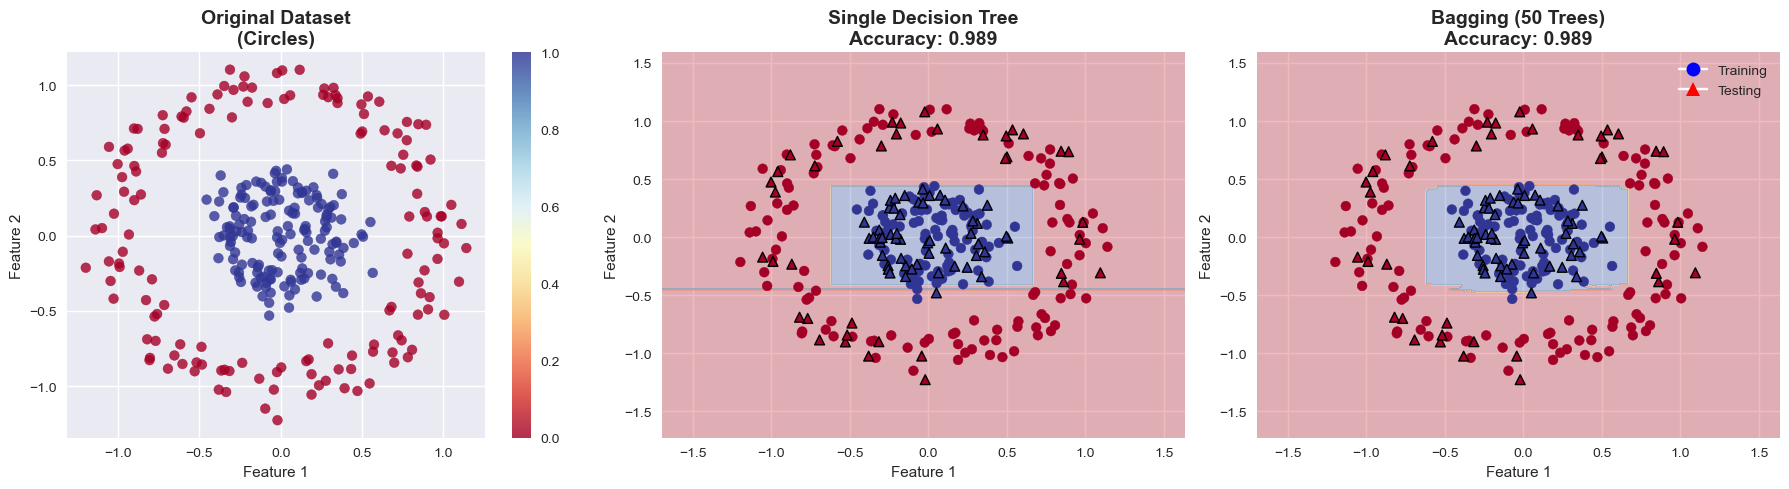


3. Individual Trees in Ensemble...


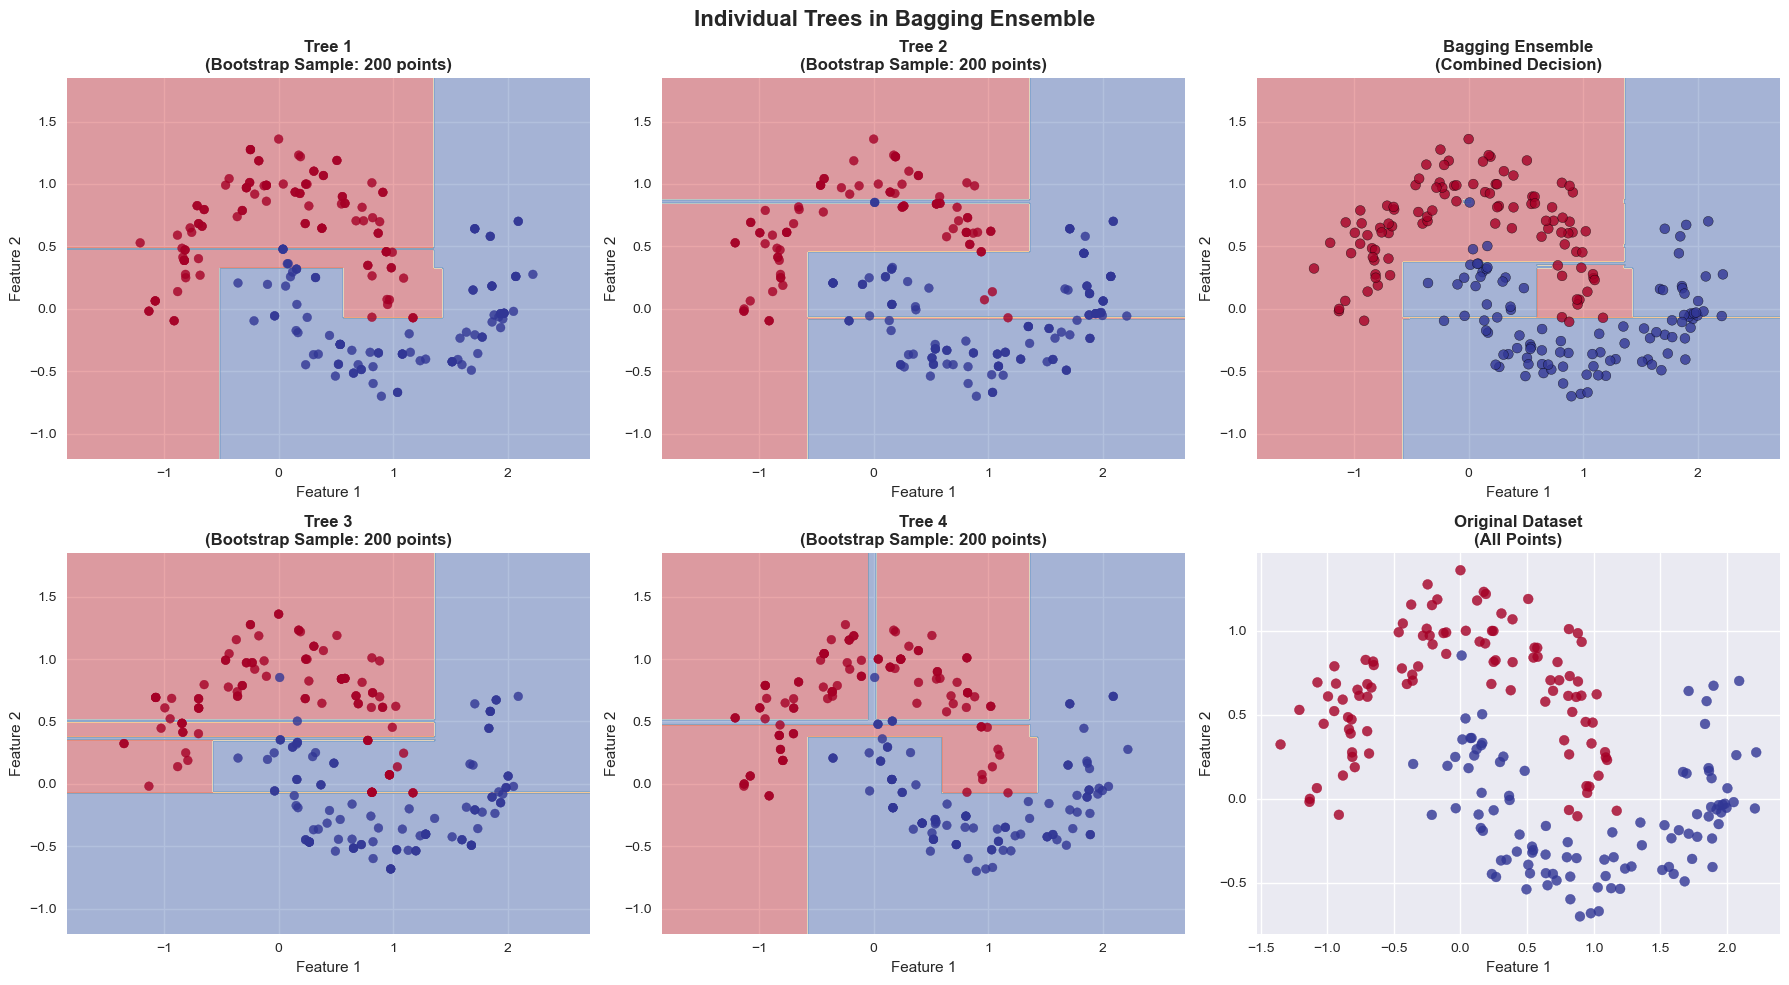


4. Performance and Variance Analysis...


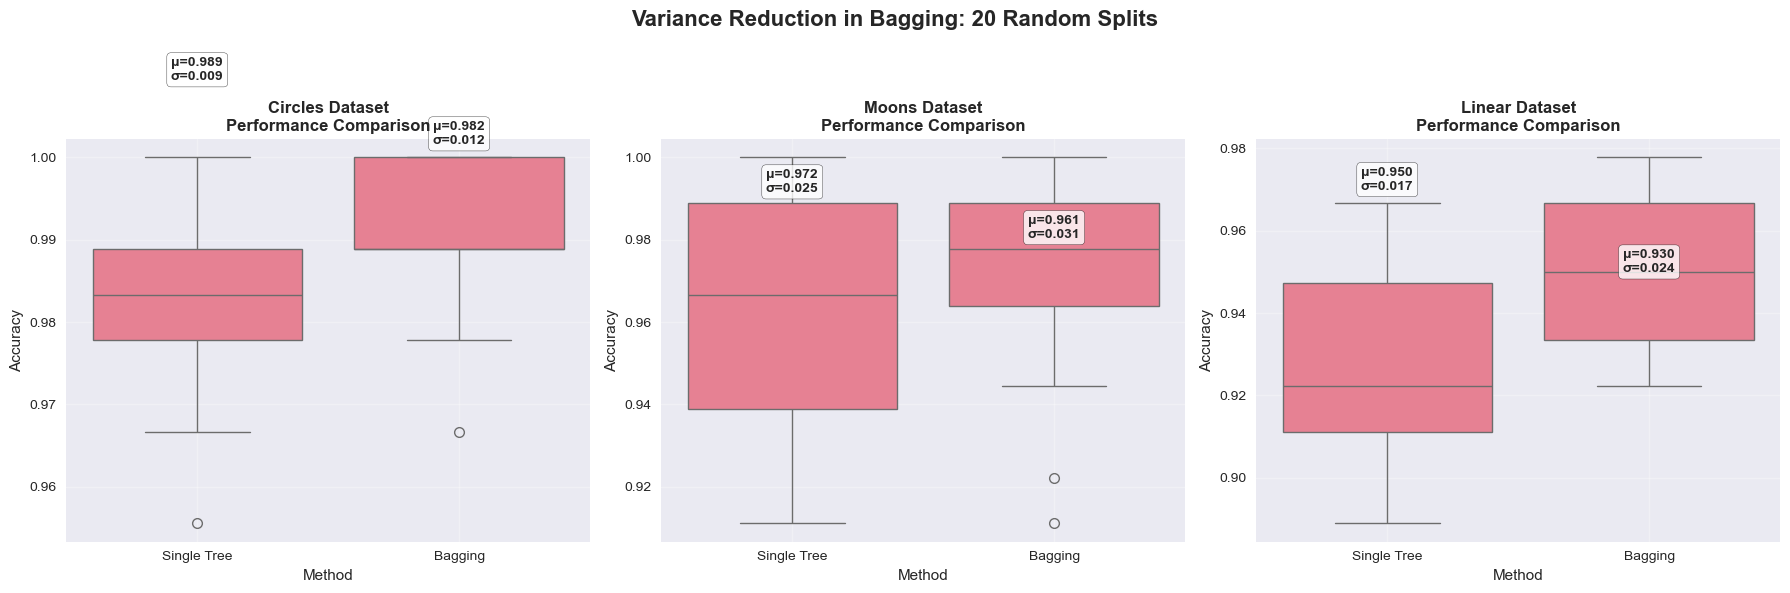


5. Learning Curves and Variance Reduction...


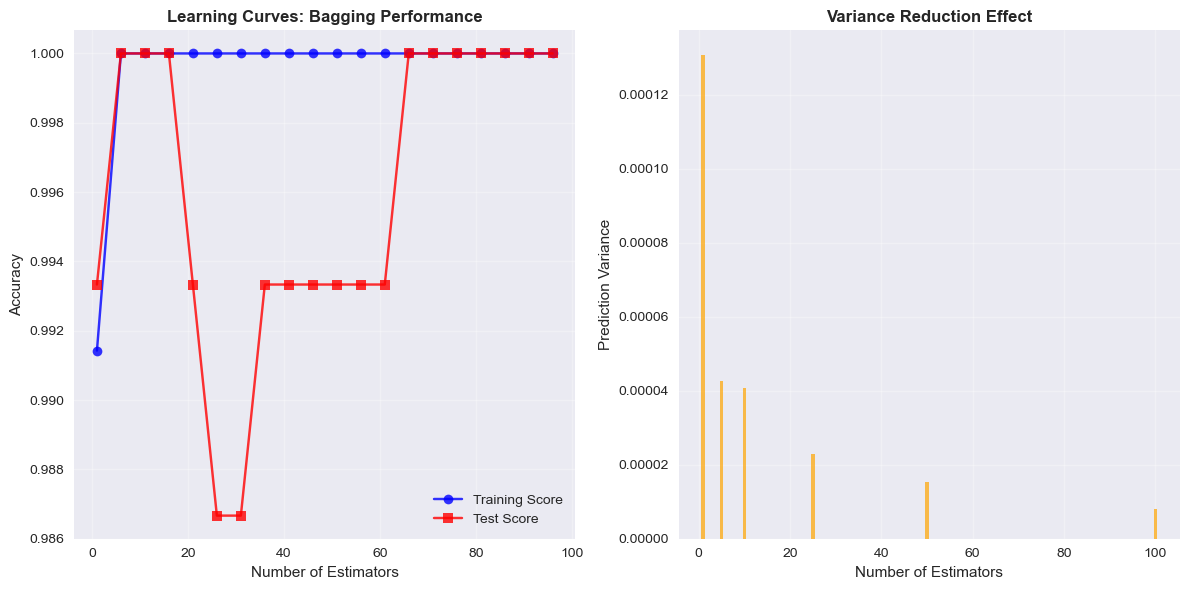


 All visualizations complete!

Key Takeaways:
• Bootstrap sampling creates diverse training sets
• Individual trees make different decisions
• Ensemble smooths decision boundaries
• Bagging reduces variance and improves stability
• More estimators generally improve performance


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_circles, make_moons
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# 1. Bootstrap Sampling Visualization
# =============================================================================

def visualize_bootstrap_sampling():
    """Visualize how bootstrap sampling works"""
    
    # Create original dataset
    np.random.seed(42)
    original_data = np.arange(1, 21)  # [1, 2, 3, ..., 20]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Bootstrap Sampling Visualization', fontsize=16, fontweight='bold')
    
    # Plot original data
    axes[0, 0].bar(range(len(original_data)), original_data, color='steelblue', alpha=0.7)
    axes[0, 0].set_title('Original Dataset', fontweight='bold')
    axes[0, 0].set_xlabel('Index')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Generate and plot bootstrap samples
    colors = ['coral', 'lightgreen', 'gold', 'plum', 'lightcyan']
    
    for i in range(5):
        row = (i + 1) // 3
        col = (i + 1) % 3
        
        # Generate bootstrap sample
        bootstrap_sample = np.random.choice(original_data, size=len(original_data), replace=True)
        unique_vals, counts = np.unique(bootstrap_sample, return_counts=True)
        
        # Create bar plot showing frequency
        freq_data = np.zeros(len(original_data))
        for val, count in zip(unique_vals, counts):
            freq_data[val-1] = count
            
        bars = axes[row, col].bar(range(len(original_data)), freq_data, 
                                 color=colors[i], alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Highlight missing values (OOB)
        oob_elements = set(original_data) - set(bootstrap_sample)
        for oob in oob_elements:
            bars[oob-1].set_color('red')
            bars[oob-1].set_alpha(0.3)
        
        axes[row, col].set_title(f'Bootstrap Sample {i+1}\nOOB: {sorted(list(oob_elements))}', 
                                fontweight='bold')
        axes[row, col].set_xlabel('Original Data Index')
        axes[row, col].set_ylabel('Frequency in Sample')
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].set_ylim(0, 4)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 2. Decision Boundary Visualization
# =============================================================================

def plot_decision_boundaries():
    """Compare decision boundaries: Single Tree vs Bagging"""
    
    # Generate non-linear dataset
    X, y = make_circles(n_samples=300, noise=0.1, factor=0.3, random_state=42)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Create models
    single_tree = DecisionTreeClassifier(max_depth=8, random_state=42)
    bagging = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8), 
                               n_estimators=50, random_state=42)
    
    # Train models
    single_tree.fit(X_train, y_train)
    bagging.fit(X_train, y_train)
    
    # Create mesh for decision boundary
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Dataset visualization
    scatter = axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=50, alpha=0.8)
    axes[0].set_title('Original Dataset\n(Circles)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=axes[0])
    
    # Single Decision Tree
    Z1 = single_tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z1 = Z1.reshape(xx.shape)
    
    axes[1].contourf(xx, yy, Z1, alpha=0.3, cmap='RdYlBu')
    scatter1 = axes[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', s=50)
    axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', s=50, 
                   marker='^', edgecolors='black', linewidth=1)
    axes[1].set_title(f'Single Decision Tree\nAccuracy: {single_tree.score(X_test, y_test):.3f}', 
                     fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    
    # Bagging
    Z2 = bagging.predict(np.c_[xx.ravel(), yy.ravel()])
    Z2 = Z2.reshape(xx.shape)
    
    axes[2].contourf(xx, yy, Z2, alpha=0.3, cmap='RdYlBu')
    scatter2 = axes[2].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', s=50)
    axes[2].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', s=50, 
                   marker='^', edgecolors='black', linewidth=1)
    axes[2].set_title(f'Bagging (50 Trees)\nAccuracy: {bagging.score(X_test, y_test):.3f}', 
                     fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Feature 1')
    axes[2].set_ylabel('Feature 2')
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Training'),
                      Line2D([0], [0], marker='^', color='w', markerfacecolor='red', markersize=10, 
                             markeredgecolor='black', label='Testing')]
    axes[2].legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 3. Individual Trees Visualization in Bagging
# =============================================================================

def visualize_individual_trees():
    """Show how individual trees in bagging make different decisions"""
    
    # Create simple 2D dataset
    X, y = make_moons(n_samples=200, noise=0.15, random_state=42)
    
    # Create bagging classifier
    bagging = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), 
                               n_estimators=4, random_state=42)
    bagging.fit(X, y)
    
    # Create mesh
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Plot individual trees and final ensemble
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Individual Trees in Bagging Ensemble', fontsize=16, fontweight='bold')
    
    # Plot first 4 individual trees
    for i in range(4):
        row = i // 2
        col = i % 2
        
        # Get individual tree
        tree = bagging.estimators_[i]
        
        # Get bootstrap indices for this tree
        bootstrap_indices = bagging.estimators_samples_[i]
        X_bootstrap = X[bootstrap_indices]
        y_bootstrap = y[bootstrap_indices]
        
        # Predict on mesh
        Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Plot decision boundary
        axes[row, col].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
        
        # Plot bootstrap samples
        scatter = axes[row, col].scatter(X_bootstrap[:, 0], X_bootstrap[:, 1], 
                                       c=y_bootstrap, cmap='RdYlBu', s=40, alpha=0.8)
        
        axes[row, col].set_title(f'Tree {i+1}\n(Bootstrap Sample: {len(bootstrap_indices)} points)', 
                               fontweight='bold')
        axes[row, col].set_xlabel('Feature 1')
        axes[row, col].set_ylabel('Feature 2')
    
    # Plot original dataset
    axes[1, 2].scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=50, alpha=0.8)
    axes[1, 2].set_title('Original Dataset\n(All Points)', fontweight='bold')
    axes[1, 2].set_xlabel('Feature 1')
    axes[1, 2].set_ylabel('Feature 2')
    
    # Plot ensemble prediction
    Z_ensemble = bagging.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_ensemble = Z_ensemble.reshape(xx.shape)
    
    axes[0, 2].contourf(xx, yy, Z_ensemble, alpha=0.4, cmap='RdYlBu')
    axes[0, 2].scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=50, alpha=0.8, edgecolors='black')
    axes[0, 2].set_title('Bagging Ensemble\n(Combined Decision)', fontweight='bold')
    axes[0, 2].set_xlabel('Feature 1')
    axes[0, 2].set_ylabel('Feature 2')
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 4. Performance Comparison with Error Bars
# =============================================================================

def performance_comparison():
    """Compare performance with multiple runs and visualize variance reduction"""
    
    # Generate different types of datasets
    datasets = {
        'Circles': make_circles(n_samples=300, noise=0.1, factor=0.3, random_state=42),
        'Moons': make_moons(n_samples=300, noise=0.15, random_state=42),
        'Linear': make_classification(n_samples=300, n_features=2, n_redundant=0, 
                                    n_informative=2, n_clusters_per_class=1, random_state=42)
    }
    
    results = {'Dataset': [], 'Method': [], 'Accuracy': [], 'Run': []}
    
    # Run experiments
    for dataset_name, (X, y) in datasets.items():
        for run in range(20):  # 20 different random splits
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=run
            )
            
            # Single Decision Tree
            single_tree = DecisionTreeClassifier(max_depth=8, random_state=run)
            single_tree.fit(X_train, y_train)
            single_acc = single_tree.score(X_test, y_test)
            
            results['Dataset'].append(dataset_name)
            results['Method'].append('Single Tree')
            results['Accuracy'].append(single_acc)
            results['Run'].append(run)
            
            # Bagging
            bagging = BaggingClassifier(
                estimator=DecisionTreeClassifier(max_depth=8),
                n_estimators=50, 
                random_state=run
            )
            bagging.fit(X_train, y_train)
            bagging_acc = bagging.score(X_test, y_test)
            
            results['Dataset'].append(dataset_name)
            results['Method'].append('Bagging')
            results['Accuracy'].append(bagging_acc)
            results['Run'].append(run)
    
    # Create DataFrame and plot
    df = pd.DataFrame(results)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, dataset in enumerate(['Circles', 'Moons', 'Linear']):
        dataset_df = df[df['Dataset'] == dataset]
        
        # Box plot
        sns.boxplot(data=dataset_df, x='Method', y='Accuracy', ax=axes[i])
        axes[i].set_title(f'{dataset} Dataset\nPerformance Comparison', fontweight='bold')
        axes[i].set_ylabel('Accuracy')
        axes[i].grid(True, alpha=0.3)
        
        # Add mean values as text
        for j, method in enumerate(['Bagging', 'Single Tree']):
            method_data = dataset_df[dataset_df['Method'] == method]['Accuracy']
            mean_val = method_data.mean()
            std_val = method_data.std()
            axes[i].text(j, mean_val + 0.02, f'μ={mean_val:.3f}\nσ={std_val:.3f}', 
                        ha='center', fontweight='bold', 
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle('Variance Reduction in Bagging: 20 Random Splits', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================================================
# 5. Learning Curves: Number of Estimators
# =============================================================================

def learning_curves():
    """Show how performance improves with more estimators"""
    
    # Create dataset
    X, y = make_circles(n_samples=500, noise=0.1, factor=0.3, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Test different numbers of estimators
    n_estimators_range = range(1, 101, 5)
    train_scores = []
    test_scores = []
    
    for n_est in n_estimators_range:
        bagging = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=8),
            n_estimators=n_est,
            random_state=42
        )
        bagging.fit(X_train, y_train)
        
        train_score = bagging.score(X_train, y_train)
        test_score = bagging.score(X_test, y_test)
        
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    # Plot learning curves
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(n_estimators_range, train_scores, 'o-', color='blue', label='Training Score', alpha=0.8)
    plt.plot(n_estimators_range, test_scores, 's-', color='red', label='Test Score', alpha=0.8)
    plt.xlabel('Number of Estimators')
    plt.ylabel('Accuracy')
    plt.title('Learning Curves: Bagging Performance', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Show variance reduction
    plt.subplot(1, 2, 2)
    variances = []
    
    for n_est in [1, 5, 10, 25, 50, 100]:
        scores = []
        for random_state in range(30):
            bagging = BaggingClassifier(
                estimator=DecisionTreeClassifier(max_depth=8),
                n_estimators=n_est,
                random_state=random_state
            )
            bagging.fit(X_train, y_train)
            scores.append(bagging.score(X_test, y_test))
        variances.append(np.var(scores))
    
    plt.bar([1, 5, 10, 25, 50, 100], variances, color='orange', alpha=0.7)
    plt.xlabel('Number of Estimators')
    plt.ylabel('Prediction Variance')
    plt.title('Variance Reduction Effect', fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# Main Execution
# =============================================================================

if __name__ == "__main__":
    print(" Bagging Visualization Examples")
    print("=" * 50)
    
    print("\n1. Bootstrap Sampling Process...")
    visualize_bootstrap_sampling()
    
    print("\n2. Decision Boundary Comparison...")
    plot_decision_boundaries()
    
    print("\n3. Individual Trees in Ensemble...")
    visualize_individual_trees()
    
    print("\n4. Performance and Variance Analysis...")
    performance_comparison()
    
    print("\n5. Learning Curves and Variance Reduction...")
    learning_curves()
    
    print("\n All visualizations complete!")
    print("\nKey Takeaways:")
    print("• Bootstrap sampling creates diverse training sets")
    print("• Individual trees make different decisions")
    print("• Ensemble smooths decision boundaries")
    print("• Bagging reduces variance and improves stability")
    print("• More estimators generally improve performance")